In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv("Wine dataset.csv")
df.head(5)

,class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


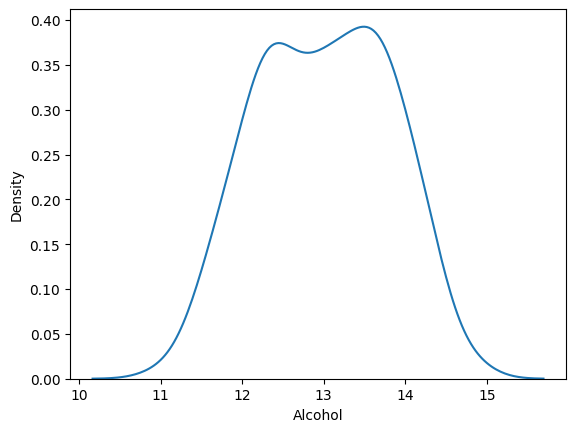

In [3]:
df_columns = ['class', 'Alcohol', 'Malic acid']

sns.kdeplot(df['Alcohol'])
plt.show()

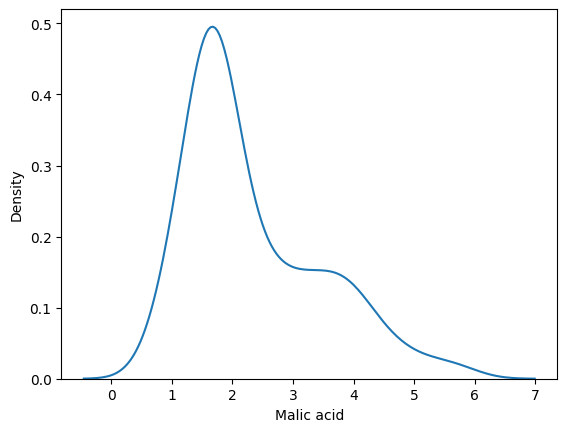

In [4]:
sns.kdeplot(df['Malic acid'])
plt.show()

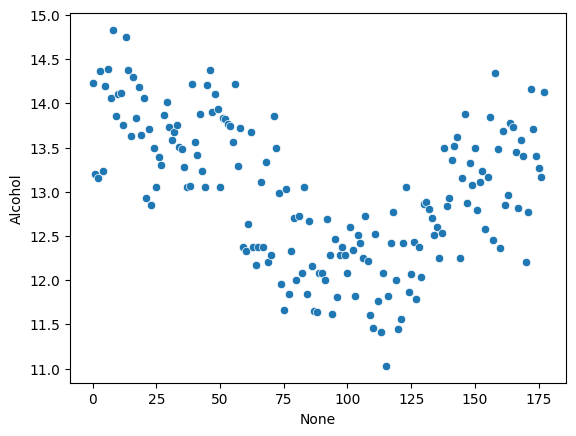

In [5]:
color_dict = {1: 'red', 2: 'blue', 3: 'green'}

sns.scatterplot(x=df.index, y=df['Alcohol'])
plt.show()

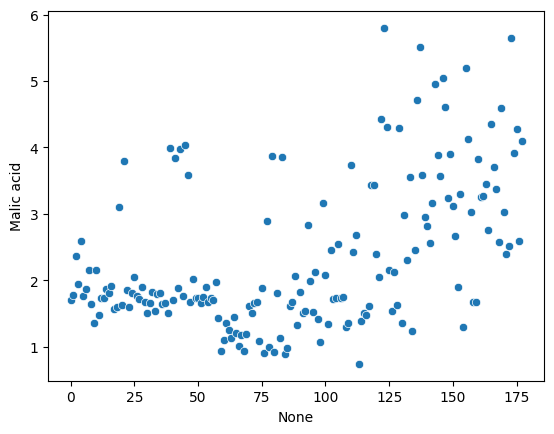

In [6]:
sns.scatterplot(x=df.index, y=df['Malic acid'])
plt.show()

In [7]:
x_train, x_test, y_train, y_test = train_test_split(
    df.drop('class', axis=1), 
    df['class'], 
    test_size=0.3, 
    random_state=0
)

scalar = MinMaxScaler()
scalar.fit(x_train)

x_train_scaled = pd.DataFrame(scalar.transform(x_train), columns=x_train.columns)
x_test_scaled = pd.DataFrame(scalar.transform(x_test), columns=x_test.columns)

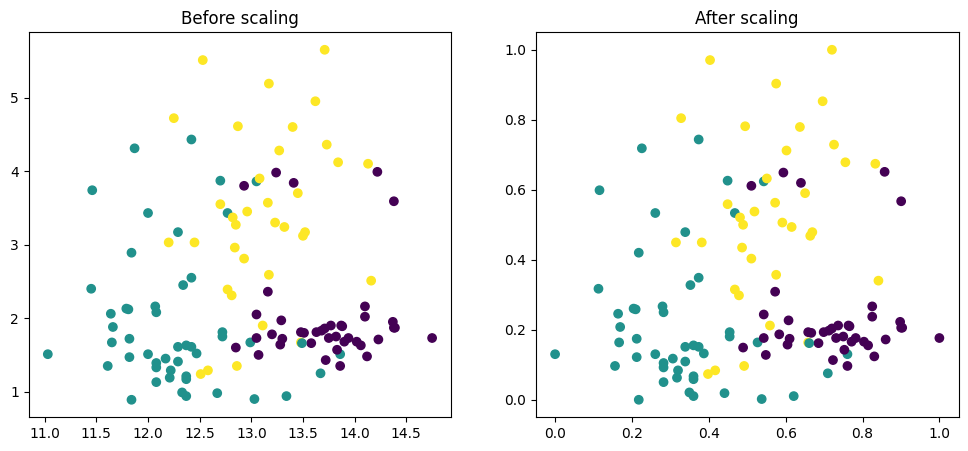

In [8]:
np.round(x_train.describe(), 1)

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
ax1.scatter(x_train['Alcohol'], x_train['Malic acid'], c=y_train)
ax1.set_title("Before scaling")
ax2.scatter(x_train_scaled['Alcohol'], x_train_scaled['Malic acid'], c=y_train)
ax2.set_title("After scaling")
plt.show()

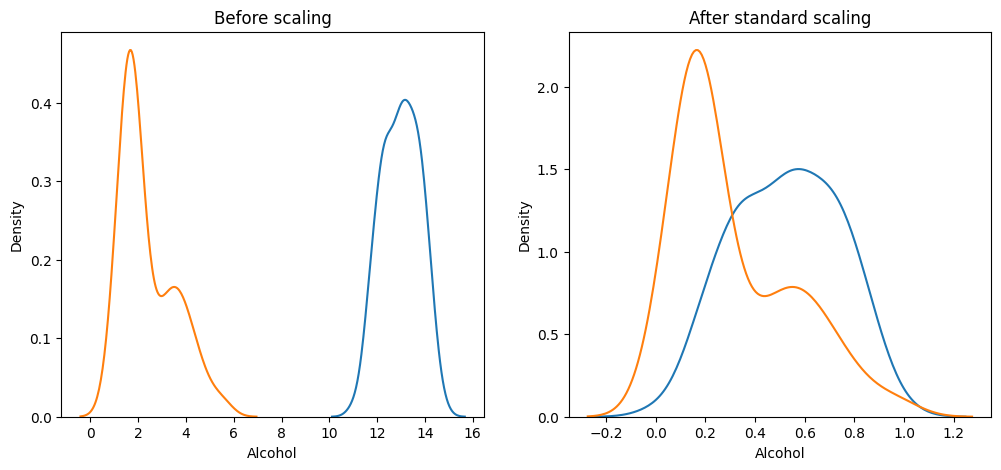

In [9]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))
ax1.set_title('Before scaling')
sns.kdeplot(x_train['Alcohol'], ax=ax1)
sns.kdeplot(x_train['Malic acid'], ax=ax1)
ax2.set_title('After standard scaling')
sns.kdeplot(x_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(x_train_scaled['Malic acid'], ax=ax2)
plt.show()